# Example File for Final Project

This notebook provides an example to generate a TRISO cylindrical compact placed in an hexagonal graphite matrix.  The data provided does not match the geometry of the project so this should be used as a guide only.

In [1]:
%matplotlib inline
import openmc
import openmc.deplete
import matplotlib.pyplot as plt

In [2]:
openmc.config['cross_sections'] = '/home/ralitsam/endfb-vii.1-hdf5/cross_sections.xml'

In [3]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U238', 0.7502, 'wo')
fuel.add_nuclide('U235', 0.1376, 'wo')
fuel.add_nuclide('O16', 0.0897, 'wo')
fuel.add_nuclide('C0', 0.0224, 'wo')
fuel.set_density('g/cc', 10.5)

buff = openmc.Material(name='Buffer')
buff.add_nuclide('C0', 1.0, 'wo')
buff.set_density('g/cm3', 1.0)

iPyC = openmc.Material(name='iPyC')
iPyC.add_nuclide('C0', 1.0, 'wo')
iPyC.set_density('g/cm3', 1.9)

oPyC = openmc.Material(name='oPyC')
oPyC.add_nuclide('C0', 1.0, 'wo')
oPyC.set_density('g/cm3', 1.9)

SiC = openmc.Material(name='SiC')
SiC.add_nuclide('C0', 0.5, 'wo')
SiC.add_element('Si', 0.5, 'wo')
SiC.set_density('g/cm3', 3.2)

coolant = openmc.Material(name='coolant')
#NaFZrF4
coolant.add_nuclide('F19',0.4537, 'wo')
coolant.add_nuclide('Na23',0.1475, 'wo')
coolant.add_nuclide('Zr91',0.3988, 'wo')
coolant.set_density('g/cm3',2.96)
print('Done')

Done


In [4]:
graphite = openmc.Material(name='moderator')
graphite.add_nuclide('C0',  0.99998985, 'wo')
graphite.add_nuclide('B10', 0.00000015, 'wo')
graphite.add_nuclide('N14', 0.00001, 'wo')
graphite.set_density('g/cc', 1.65)

In [5]:
materials_file = openmc.Materials([fuel, graphite, buff, iPyC, oPyC, SiC,coolant])
materials_file.export_to_xml()

In [6]:
fuel.temperature = 1000
buff.temperature = 900
iPyC.temperature = 900
oPyC.temperature = 900
SiC.temperature = 900
coolant.temperature = 900
graphite.temperature = 900

This block defines a fuel radius and a slightly smaller compact radius to avoid situations where TRISOs would be cut by the boundary.

In [7]:
top = openmc.ZPlane(surface_id=4, z0=+1, boundary_type='periodic')
bottom = openmc.ZPlane(surface_id=5, z0=-1, boundary_type='periodic') 

# Geometry definitions
fuel_radius = openmc.ZCylinder(surface_id=1, r=0.635) 
coolant_radius = openmc.ZCylinder(surface_id=2, r=0.35) 

compact_radius = openmc.ZCylinder(surface_id=6, r=0.635) 

top_compact = openmc.ZPlane(surface_id=7, z0=+0.999)
bottom_compact = openmc.ZPlane(surface_id=8, z0=-0.999) 

region = -compact_radius & -top_compact & +bottom_compact

fuel_region = -fuel_radius
moder_fuel = +fuel_radius
coolant_region = -coolant_radius 
moder_coolant = +coolant_radius 
 
fuel_cell = openmc.Cell(cell_id=1, fill=fuel, region=fuel_region)
moder_fuel_cell = openmc.Cell(cell_id=2, fill=graphite, region=moder_fuel)
graphite_cell = openmc.Cell(cell_id=3, fill=graphite)

coolant_cell = openmc.Cell(cell_id=4, fill=coolant, region=coolant_region)
moder_coolant_cell = openmc.Cell(cell_id=5, fill=graphite, region=moder_coolant)

This block creates a TRISO universe.

In [8]:
# Create TRISO universe
spheres = [openmc.Sphere(r=1e-4*r)
           for r in [212.5, 312.5, 347.5, 382.5]]
#spheres = [openmc.Sphere(r=r)
 #          for r in [0.02125, 0.03125, 0.03475, 0.03825]]
cells = [openmc.Cell(fill=fuel, region=-spheres[0]),
         openmc.Cell(fill=buff, region=+spheres[0] & -spheres[1]),
         openmc.Cell(fill=iPyC, region=+spheres[1] & -spheres[2]),
         openmc.Cell(fill=SiC, region=+spheres[2] & -spheres[3]),
         openmc.Cell(fill=oPyC, region=+spheres[3])]
triso_univ = openmc.Universe(cells=cells)

This block places spheres of a given size in a region with a user defined packing fraction.  As the packing fraction gets larger, the run time increases substantially.

In [9]:
outer_radius = 422.5*1e-4
#print(domain.volume)
centers = openmc.model.pack_spheres(radius=outer_radius, region=region, pf=0.35)

This block assigns a triso universe to each sphere.

In [10]:
trisos = [openmc.model.TRISO(outer_radius, triso_univ, center) for center in centers]

This block creates a lattice over the TRISO region for acceleration purposes.  A virtual mesh is added and a list of TRISOs in each mesh cell is calculated.  Thus, when in a given cell, the nearest neighbor search is limited to surfaces in the mesh.

In [11]:
lower_left, upper_right = fuel_cell.region.bounding_box
lower_left[2] = -1.0
upper_right[2] = 1.0
shape = (3, 3, 3)
pitch = (upper_right - lower_left)/shape
lattice = openmc.model.create_triso_lattice(
    trisos, lower_left, pitch, shape, graphite)

fuel_cell.fill = lattice

In [12]:
fuel_u = openmc.Universe(universe_id=1001, cells=(fuel_cell,moder_fuel_cell))
graphite_u = openmc.Universe(universe_id=1002, cells=[graphite_cell])
coolant_u = openmc.Universe(universe_id=1005, cells=[coolant_cell,moder_coolant_cell])

In [13]:
inner = [coolant_u]
outer = [coolant_u,fuel_u,coolant_u,fuel_u,coolant_u,fuel_u]

An hexagonal lattice is defined with a fuel universe surrounded by a graphite universe.

In [14]:
hex_lat = openmc.HexLattice(lattice_id=1003, name='assembly')
hex_lat.center = (0., 0.)
hex_lat.pitch = (1.8796,)
hex_lat.orientation = 'x'
hex_lat.outer = graphite_u
hex_lat.universes = [outer, inner]

An hexagonal bounding box is defined around the lattice.

In [15]:
# Create the prism that will contain the lattice
outer_surface = openmc.model.hexagonal_prism(edge_length=2.8194, orientation='x', boundary_type='periodic')

/home/ralitsam/.conda/envs/openmc-env/lib/python3.12/site-packages/openmc/model/funcs.py:124: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


In [16]:
# Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism.
main_assembly = openmc.Cell(cell_id=7000, fill=hex_lat, region=outer_surface & -top & +bottom)

# Create a universe that contains both 
root = openmc.Universe(cells=[main_assembly])

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

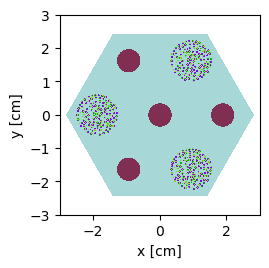

In [17]:
root.plot(origin = (0,0,0), pixels=(200, 200), width = (6.,6.), color_by = 'material')

In [18]:
geom = openmc.Geometry(root)
geom.export_to_xml()

In [19]:
# OpenMC simulation parameters

lower_left = [-3, -3, -1]
upper_right = [3, 3, 1]
uniform_dist = openmc.stats.Box(lower_left, upper_right)
src = openmc.IndependentSource(space=uniform_dist)#, constraints={'fissionable': True})

settings = openmc.Settings()
settings.source = src
settings.batches = 100
settings.inactive = 25
settings.particles = 2000
settings.temperature = {'method': 'interpolation','range':(293.15,1923.15)}

settings.export_to_xml()

In [20]:
%matplotlib inline
import openmc.examples
import numpy as np
import matplotlib.pyplot as plt

In [21]:
model = openmc.examples.pwr_pin_cell()

In [22]:
# Create equal-lethargy energy filter
import numpy as np
# Energy filters
energies = np.logspace(np.log10(1e-5), np.log10(20.0e6), 501)
e_filter = openmc.EnergyFilter(energies)
shem_filter = openmc.EnergyFilter(openmc.mgxs.GROUP_STRUCTURES['SHEM-361'])

# Cell filters
flux_cells = [fuel_cell, graphite_cell, coolant_cell, moder_fuel_cell, moder_coolant_cell]
fuel_cell_filter = openmc.CellFilter(fuel_cell)
graph_cell_filter = openmc.CellFilter([graphite_cell, moder_coolant_cell, moder_fuel_cell])
cool_cell_filter = openmc.CellFilter(coolant_cell)

# Tallies
fuel_flux_tally = openmc.Tally(name='lethargy_flux_fuel')
fuel_flux_tally.filters = [e_filter, fuel_cell_filter]
fuel_flux_tally.scores = ['flux']

fuel_heating_tally = openmc.Tally(name='fuel_heating')
fuel_heating_tally.filters = [fuel_cell_filter]
fuel_heating_tally.scores = ['heating']

graph_flux_tally = openmc.Tally(name='lethargy_flux_graphite')
graph_flux_tally.filters = [e_filter, graph_cell_filter]
graph_flux_tally.scores = ['flux']

graph_heating_tally = openmc.Tally (name='graphite_heating')
graph_heating_tally.filters = [graph_cell_filter]
graph_heating_tally.scores = ['heating']

cool_flux_tally = openmc.Tally(name='lethargy_flux_coolant')
cool_flux_tally.filters = [e_filter, cool_cell_filter]
cool_flux_tally.scores = ['flux']

cool_heating_tally = openmc.Tally(name='coolant_heating')
cool_heating_tally.filters = [cool_cell_filter]
cool_heating_tally.scores = ['heating']

shem_tally = openmc.Tally(name='shem_flux')
shem_tally.filters = [shem_filter]
shem_tally.scores = ['flux']

# Collect tallies
tallies = openmc.Tallies([shem_tally, fuel_flux_tally, graph_flux_tally, cool_flux_tally, fuel_heating_tally, graph_heating_tally, cool_heating_tally])

# Export
tallies.export_to_xml()

In [23]:
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

Fuel flux shape: (500,)


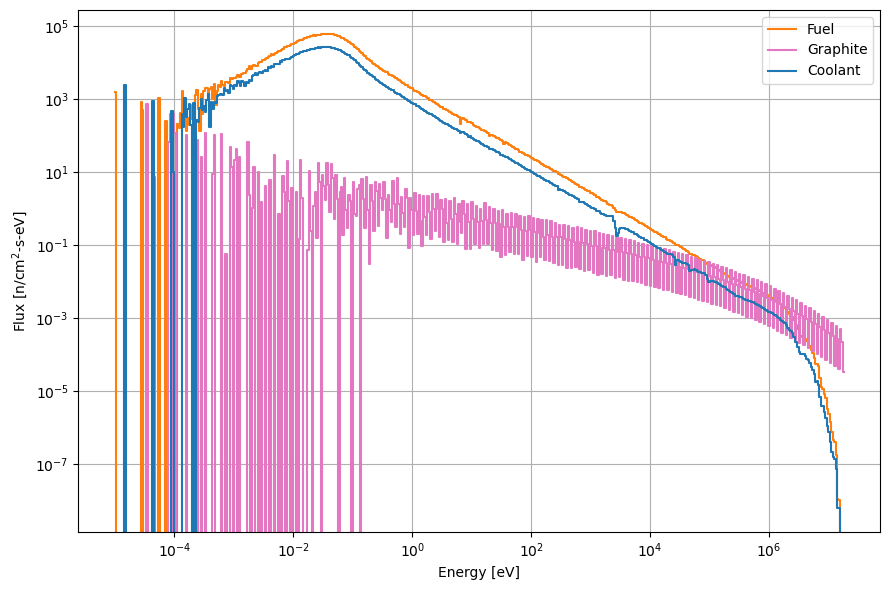

In [30]:
import numpy as np

# Load the statepoint file
sp = openmc.StatePoint('statepoint.100.h5')

# Get tallies
fuel_flux = sp.get_tally(name='lethargy_flux_fuel')
graph_flux = sp.get_tally(name='lethargy_flux_graphite')
cool_flux = sp.get_tally(name='lethargy_flux_coolant')

# Extract flux values
fluxf = fuel_flux.get_values(scores=['flux']).squeeze()
fluxg = graph_flux.get_values(scores=['flux']).squeeze()
fluxc = cool_flux.get_values(scores=['flux']).squeeze()

# Extract energy bins
energy_filter = fuel_flux.find_filter(openmc.EnergyFilter)
energies = energy_filter.bins
energy_midpoints = energies

print(f"Fuel flux shape: {fluxf.shape}")

# Correct slicing
fluxf = fluxf[:499]
fluxg = fluxg[:499]
fluxc = fluxc[:499]

# Bin widths and midpoints (length 499)
dE = np.diff(energies[:, -1])
energy_mid = energy_midpoints[:-1, 0]

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.loglog(energy_mid, 1000 * fluxf / dE, label='Fuel', drawstyle='steps-mid', color='#ff7f0e')     # pink
plt.loglog(energy_mid, 1000 * fluxg / dE, label='Graphite', drawstyle='steps-mid', color='#e377c2') # orange
plt.loglog(energy_mid, 1000 * fluxc / dE, label='Coolant', drawstyle='steps-mid', color='#1f77b4')  # light blue

plt.xlabel('Energy [eV]')
plt.ylabel('Flux [n/cm$^2$-s-eV]')
plt.legend()
plt.grid(True, which='both')
plt.tight_layout()
plt.savefig('flux_spectrum.png', dpi=600, bbox_inches='tight')
plt.show()


In [25]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    'Energy (eV)': energy_mid,
    'Flux Fuel [n/cm^2-s-eV]': 1000 * fluxf / dE,
    'Flux Graphite [n/cm^2-s-eV]': 1000 * fluxg / dE,
    'Flux Coolant [n/cm^2-s-eV]': 1000 * fluxc / dE
})

# Save to CSV
df.to_csv('flux_spectrum_export.csv', index=False)

In [26]:
# Create depletion "operator"
model = openmc.Model(geometry=geom, materials=materials_file, settings=settings)
op = openmc.deplete.CoupledOperator(model, "chain_casl_pwr.xml")

# Perform simulation using the predictor algorithm
time_steps = [1.0, 2.0, 10.0, 20.0, 30.0]  # days
power = 1000  
integrator = openmc.deplete.PredictorIntegrator(op, time_steps, power, timestep_units='d')
integrator.integrate()

OSError: Error reading file 'chain_casl_pwr.xml': failed to load "chain_casl_pwr.xml": No such file or directory

In [ ]:
# Open results file
results = openmc.deplete.ResultsList.from_hdf5("depletion_results.h5")

# Obtain K_eff as a function of time
time, keff = results.get_eigenvalue()

# Obtain U235 concentration as a function of time
time, n_U235 = results.get_atoms('1', 'U235')

###############################################################################
#                            Generate plots
###############################################################################

days = 24*60*60
plt.figure()
plt.plot(time/days, keff[:,0], label="K-effective")
plt.xlabel("Time (days)")
plt.ylabel("Keff")
plt.show()

plt.figure()
plt.plot(time/days, n_U235, label="U235")
plt.xlabel("Time (days)")
plt.ylabel("n U5 (-)")
plt.show()


In [ ]:
print(results)

In [ ]:
with openmc.StatePoint(sp_path) as sp:
    t = sp.tallies[tally.id]
    flux500_mean = t.mean.ravel()
    flux500_unc = t.std_dev.ravel()